# SASRec + LightGCN Score-level Fusion Experiments

This notebook implements the full experimental pipeline for the movie recommendation project:

1. Load and preprocess MovieLens data.
2. Build a **shared chronological holdout multi-positive protocol**.
3. Train **SASRec**.
4. Train **LightGCN**.
5. Export per-user candidate scores from both models.
6. Run **score-level fusion** with alpha sweep.
7. Run **score normalization ablation**.
8. Evaluate Recall@K and NDCG@K.
9. Analyze popularity bias and long-tail recommendation behavior.

Main shared protocol:

For each user, interactions are sorted by timestamp.

- First 80% interactions → training history / training graph
- Last 20% interactions → test positives

This protocol preserves temporal order for SASRec while still allowing LightGCN to operate in a multi-positive top-K retrieval setting.

## 0. Setup

Change `DATA_PATH` below to match your dataset location.

Supported formats:

- `ratings.csv` with columns: `userId`, `movieId`, `timestamp`
- MovieLens 1M `ratings.dat` with format: `UserID::MovieID::Rating::Timestamp`

In [ ]:
import os
import math
import random
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

SEED = 42

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

!wget -q https://files.grouplens.org/datasets/movielens/ml-1m.zip
!unzip -o -q ml-1m.zip


CONFIG = {
    "DATA_PATH": "ml-1m/ratings.dat",   # change to your path
    "MIN_USER_INTERACTIONS": 5,
    "TRAIN_RATIO": 0.8,
    "MAX_LEN": 50,
    "BATCH_SIZE": 512,
    "SASREC_HIDDEN_DIM": 128,
    "SASREC_NUM_HEADS": 4,
    "SASREC_NUM_LAYERS": 2,
    "SASREC_DROPOUT": 0.3,
    "SASREC_LR": 1e-3,
    "SASREC_EPOCHS": 30,
    "SASREC_WEIGHT_DECAY": 1e-5,
    "LIGHTGCN_EMB_DIM": 128,
    "LIGHTGCN_LAYERS": 4,
    "LIGHTGCN_LR": 1e-3,
    "LIGHTGCN_WEIGHT_DECAY": 1e-4,
    "LIGHTGCN_EPOCHS": 200,
    "BPR_BATCH_SIZE": 4096,
    "EVAL_KS": [10, 20],
    "CURVE_MAX_K": 30,
    "ALPHAS": [round(x, 1) for x in np.arange(0.0, 1.01, 0.1)],
}
CONFIG

Using device: cuda


{'DATA_PATH': 'ml-1m/ratings.dat',
 'MIN_USER_INTERACTIONS': 5,
 'TRAIN_RATIO': 0.8,
 'MAX_LEN': 50,
 'BATCH_SIZE': 512,
 'SASREC_HIDDEN_DIM': 128,
 'SASREC_NUM_HEADS': 4,
 'SASREC_NUM_LAYERS': 2,
 'SASREC_DROPOUT': 0.3,
 'SASREC_LR': 0.001,
 'SASREC_EPOCHS': 30,
 'SASREC_WEIGHT_DECAY': 1e-05,
 'LIGHTGCN_EMB_DIM': 128,
 'LIGHTGCN_LAYERS': 4,
 'LIGHTGCN_LR': 0.001,
 'LIGHTGCN_WEIGHT_DECAY': 0.0001,
 'LIGHTGCN_EPOCHS': 200,
 'BPR_BATCH_SIZE': 4096,
 'EVAL_KS': [10, 20],
 'CURVE_MAX_K': 30,
 'ALPHAS': [np.float64(0.0),
  np.float64(0.1),
  np.float64(0.2),
  np.float64(0.3),
  np.float64(0.4),
  np.float64(0.5),
  np.float64(0.6),
  np.float64(0.7),
  np.float64(0.8),
  np.float64(0.9),
  np.float64(1.0)]}

## 1. Load and preprocess MovieLens data

The notebook re-indexes users and movies into contiguous integer IDs.

Important convention:

- `0` is reserved for padding.
- User IDs use `0..n_users-1` for LightGCN embedding convenience.
- Item IDs use `1..n_items` because SASRec uses `0` as padding.
- LightGCN internally uses item indices `0..n_items-1`, so we convert when needed.

In [ ]:
def load_ratings(path):
    if path.endswith(".dat"):
        df = pd.read_csv(
            path,
            sep="::",
            engine="python",
            names=["userId", "movieId", "rating", "timestamp"],
        )
    else:
        df = pd.read_csv(path)

    required = {"userId", "movieId", "timestamp"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    df = df[["userId", "movieId", "timestamp"]].drop_duplicates()
    df = df.rename(columns={"userId": "raw_user", "movieId": "raw_movie"})
    return df


def reindex_ids(df):
    df = df.copy()

    user_cats = pd.Categorical(df["raw_user"])
    movie_cats = pd.Categorical(df["raw_movie"])

    df["user"] = user_cats.codes
    df["item"] = movie_cats.codes + 1

    n_users = df["user"].nunique()
    n_items = df["item"].nunique()

    user2idx = {raw: idx for idx, raw in enumerate(user_cats.categories)}
    idx2user = {idx: raw for raw, idx in user2idx.items()}

    movie2idx = {raw: idx + 1 for idx, raw in enumerate(movie_cats.categories)}
    idx2movie = {idx + 1: raw for idx, raw in enumerate(movie_cats.categories)}

    return df, n_users, n_items, user2idx, idx2user, movie2idx, idx2movie


df = load_ratings(CONFIG["DATA_PATH"])
df, n_users, n_items, user2idx, idx2user, movie2idx, idx2movie = reindex_ids(df)

print(f"Users: {n_users:,}")
print(f"Items: {n_items:,}")
print(f"Interactions: {len(df):,}")
df.head()

Users: 6,040
Items: 3,706
Interactions: 1,000,209


,raw_user,raw_movie,timestamp,user,item
0,1,1193,978300760,0,1105
1,1,661,978302109,0,640
2,1,914,978301968,0,854
3,1,3408,978300275,0,3178
4,1,2355,978824291,0,2163


## 2. Shared chronological holdout multi-positive split

This is the main protocol for direct comparison and fusion.

For each user:

- Sort by timestamp.
- Use the first 80% as train interactions.
- Use the last 20% as test positives.

Users with too few interactions are removed.

In [ ]:
def chronological_holdout_split(df, train_ratio=0.8, min_user_interactions=5):
    train_parts = []
    test_parts = []

    df = df.sort_values(["user", "timestamp"])

    for user, group in df.groupby("user"):
        group = group.sort_values("timestamp")
        n = len(group)

        if n < min_user_interactions:
            continue

        split_idx = int(n * train_ratio)

        # Need at least two train items for SASRec prefix training and at least one test item.
        if split_idx < 2 or split_idx >= n:
            continue

        train_parts.append(group.iloc[:split_idx])
        test_parts.append(group.iloc[split_idx:])

    train_df = pd.concat(train_parts).reset_index(drop=True)
    test_df = pd.concat(test_parts).reset_index(drop=True)

    return train_df, test_df


train_df, test_df = chronological_holdout_split(
    df,
    train_ratio=CONFIG["TRAIN_RATIO"],
    min_user_interactions=CONFIG["MIN_USER_INTERACTIONS"],
)

print(f"Train interactions: {len(train_df):,}")
print(f"Test interactions: {len(test_df):,}")
print(f"Train users: {train_df['user'].nunique():,}")
print(f"Test users: {test_df['user'].nunique():,}")

Train interactions: 797,758
Test interactions: 202,451
Train users: 6,040
Test users: 6,040


In [ ]:
def build_user_sequences(df_part):
    df_part = df_part.sort_values(["user", "timestamp"])
    return df_part.groupby("user")["item"].apply(list).to_dict()


def build_user_test_sets(df_part):
    return df_part.groupby("user")["item"].apply(lambda x: set(x.tolist())).to_dict()


user_train = build_user_sequences(train_df)
user_test = build_user_test_sets(test_df)

common_users = sorted(set(user_train.keys()) & set(user_test.keys()))
user_train = {u: user_train[u] for u in common_users}
user_test = {u: user_test[u] for u in common_users}

print(f"Users used in shared evaluation: {len(common_users):,}")
print("Example user:", common_users[0])
print("Train sequence length:", len(user_train[common_users[0]]))
print("Test positives:", len(user_test[common_users[0]]))

Users used in shared evaluation: 6,040
Example user: 0
Train sequence length: 42
Test positives: 11


## 3. Evaluation metrics

Multi-positive top-K retrieval metrics:

- `Recall@K = hits in top-K / number of test positives`
- `NDCG@K = DCG@K / IDCG@K`

Training items are masked during evaluation so the model does not recommend movies the user already interacted with in the training history.

In [ ]:
def recall_ndcg_for_user(ranked_items, true_items, k):
    topk = ranked_items[:k]
    true_items = set(true_items)

    hits = [item for item in topk if item in true_items]
    recall = len(hits) / len(true_items) if len(true_items) > 0 else 0.0

    dcg = 0.0
    for rank, item in enumerate(topk):
        if item in true_items:
            dcg += 1.0 / math.log2(rank + 2)

    ideal_hits = min(len(true_items), k)
    idcg = sum(1.0 / math.log2(rank + 2) for rank in range(ideal_hits))
    ndcg = dcg / idcg if idcg > 0 else 0.0

    return recall, ndcg


def evaluate_score_dict(score_dict, user_train, user_test, ks=(10, 20)):
    results = {f"Recall@{k}": [] for k in ks}
    results.update({f"NDCG@{k}": [] for k in ks})

    for user, scores in score_dict.items():
        if user not in user_test:
            continue

        scores = scores.copy()

        # mask padding item 0
        scores[0] = -1e9

        # mask seen training items
        for item in set(user_train[user]):
            scores[item] = -1e9

        ranked_items = np.argsort(-scores).tolist()

        for k in ks:
            recall, ndcg = recall_ndcg_for_user(ranked_items, user_test[user], k)
            results[f"Recall@{k}"].append(recall)
            results[f"NDCG@{k}"].append(ndcg)

    return {key: float(np.mean(vals)) if vals else 0.0 for key, vals in results.items()}


def evaluate_score_dict_over_k(score_dict, user_train, user_test, max_k=30):
    k_values = list(range(1, max_k + 1))
    recall_scores = []
    ndcg_scores = []

    for k in k_values:
        metrics = evaluate_score_dict(score_dict, user_train, user_test, ks=(k,))
        recall_scores.append(metrics[f"Recall@{k}"])
        ndcg_scores.append(metrics[f"NDCG@{k}"])

    return k_values, recall_scores, ndcg_scores

## 4. SASRec implementation

Important fix:

Because sequences are **left-padded**, the most recent valid item is always at the final position. Therefore, the sequence representation is:

```python
seq_repr = hidden[:, -1, :]
```

Do not use `lengths - 1` under left padding, because that is correct only for right padding.

In [ ]:
def pad_sequence(seq, max_len, pad_token=0):
    if len(seq) > max_len:
        seq = seq[-max_len:]
    if len(seq) < max_len:
        seq = [pad_token] * (max_len - len(seq)) + seq
    return seq


def build_sasrec_examples(user_train, max_len=50):
    examples = []
    for user, seq in user_train.items():
        for i in range(1, len(seq)):
            prefix = seq[:i]
            target = seq[i]
            examples.append((pad_sequence(prefix, max_len), target))
    return examples


class SASRecDataset(Dataset):
    def __init__(self, examples):
        self.examples = examples

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx):
        seq, target = self.examples[idx]
        return (
            torch.tensor(seq, dtype=torch.long),
            torch.tensor(target, dtype=torch.long),
        )


def make_sasrec_dataloader(user_train, max_len, batch_size, shuffle=True):
    examples = build_sasrec_examples(user_train, max_len=max_len)
    dataset = SASRecDataset(examples)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)


class SASRec(nn.Module):
    def __init__(
        self,
        num_items,
        max_len=50,
        hidden_dim=64,
        num_heads=2,
        num_layers=2,
        dropout=0.2,
    ):
        super().__init__()

        self.num_items = num_items
        self.max_len = max_len
        self.hidden_dim = hidden_dim

        self.item_embedding = nn.Embedding(
            num_embeddings=num_items + 1,
            embedding_dim=hidden_dim,
            padding_idx=0,
        )

        self.position_embedding = nn.Embedding(
            num_embeddings=max_len,
            embedding_dim=hidden_dim,
        )

        self.dropout = nn.Dropout(dropout)
        self.layer_norm = nn.LayerNorm(hidden_dim)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim,
            nhead=num_heads,
            dim_feedforward=hidden_dim * 4,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers,
        )

        # Optional item bias, useful for recommendation scoring.
        self.output_bias = nn.Parameter(torch.zeros(num_items + 1))

    def forward(self, input_seq):
        device = input_seq.device
        batch_size, seq_len = input_seq.shape

        positions = torch.arange(seq_len, device=device).unsqueeze(0).expand(batch_size, seq_len)

        item_emb = self.item_embedding(input_seq)
        pos_emb = self.position_embedding(positions)

        x = self.dropout(item_emb + pos_emb)

        padding_mask = (input_seq == 0)

        causal_mask = torch.triu(
            torch.ones(seq_len, seq_len, device=device),
            diagonal=1,
        ).bool()

        hidden = self.transformer(
            x,
            mask=causal_mask,
            src_key_padding_mask=padding_mask,
        )

        hidden = self.layer_norm(hidden)

        # Correct for left padding.
        seq_repr = hidden[:, -1, :]

        logits = seq_repr @ self.item_embedding.weight.T + self.output_bias
        logits = logits.clone()
        logits[:, 0] = -1e9

        return logits

## 5. Train SASRec under shared protocol

In [ ]:
def train_sasrec_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0

    for input_seq, target in dataloader:
        input_seq = input_seq.to(device)
        target = target.to(device)

        optimizer.zero_grad()
        logits = model(input_seq)
        loss = criterion(logits, target)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / max(len(dataloader), 1)


def get_sasrec_score_dict(model, user_train, max_len, device, batch_size=512):
    model.eval()
    users = list(user_train.keys())
    score_dict = {}

    with torch.no_grad():
        for start in range(0, len(users), batch_size):
            batch_users = users[start:start + batch_size]
            batch_seqs = [pad_sequence(user_train[u], max_len=max_len) for u in batch_users]
            input_tensor = torch.tensor(batch_seqs, dtype=torch.long).to(device)

            logits = model(input_tensor).detach().cpu().numpy()

            for idx, u in enumerate(batch_users):
                score_dict[u] = logits[idx]

    return score_dict


sasrec_loader = make_sasrec_dataloader(
    user_train=user_train,
    max_len=CONFIG["MAX_LEN"],
    batch_size=CONFIG["BATCH_SIZE"],
    shuffle=True,
)

sasrec_model = SASRec(
    num_items=n_items,
    max_len=CONFIG["MAX_LEN"],
    hidden_dim=CONFIG["SASREC_HIDDEN_DIM"],
    num_heads=CONFIG["SASREC_NUM_HEADS"],
    num_layers=CONFIG["SASREC_NUM_LAYERS"],
    dropout=CONFIG["SASREC_DROPOUT"],
).to(DEVICE)

criterion = nn.CrossEntropyLoss()
sasrec_optimizer = optim.Adam(sasrec_model.parameters(), lr=CONFIG["SASREC_LR"], weight_decay=CONFIG["SASREC_WEIGHT_DECAY"],)

sasrec_history = []

for epoch in range(1, CONFIG["SASREC_EPOCHS"] + 1):
    loss = train_sasrec_one_epoch(
        model=sasrec_model,
        dataloader=sasrec_loader,
        optimizer=sasrec_optimizer,
        criterion=criterion,
        device=DEVICE,
    )

    if epoch == 1 or epoch % 5 == 0 or epoch == CONFIG["SASREC_EPOCHS"]:
        sasrec_scores_tmp = get_sasrec_score_dict(
            sasrec_model, user_train, CONFIG["MAX_LEN"], DEVICE
        )
        metrics = evaluate_score_dict(
            sasrec_scores_tmp, user_train, user_test, ks=CONFIG["EVAL_KS"]
        )
        print(f"Epoch {epoch:03d} | Loss {loss:.4f} | {metrics}")
        sasrec_history.append({"epoch": epoch, "loss": loss, **metrics})
    else:
        print(f"Epoch {epoch:03d} | Loss {loss:.4f}")

sasrec_scores = get_sasrec_score_dict(
    sasrec_model, user_train, CONFIG["MAX_LEN"], DEVICE
)

sasrec_metrics = evaluate_score_dict(
    sasrec_scores, user_train, user_test, ks=CONFIG["EVAL_KS"]
)

sasrec_metrics

Epoch 001 | Loss 9.6490 | {'Recall@10': 0.01946136246233555, 'Recall@20': 0.03484647575822821, 'NDCG@10': 0.0850801966179114, 'NDCG@20': 0.07962206797523981}
Epoch 002 | Loss 7.4238
Epoch 003 | Loss 6.8829
Epoch 004 | Loss 6.4524
Epoch 005 | Loss 6.1897 | {'Recall@10': 0.04540625974359882, 'Recall@20': 0.07669607647519405, 'NDCG@10': 0.1590901385626443, 'NDCG@20': 0.14617024418227817}
Epoch 006 | Loss 6.0317
Epoch 007 | Loss 5.9193
Epoch 008 | Loss 5.8262
Epoch 009 | Loss 5.7510
Epoch 010 | Loss 5.6920 | {'Recall@10': 0.0524293068892888, 'Recall@20': 0.08891914446687257, 'NDCG@10': 0.18048435614845146, 'NDCG@20': 0.16535408378605354}
Epoch 011 | Loss 5.6456
Epoch 012 | Loss 5.6066
Epoch 013 | Loss 5.5777
Epoch 014 | Loss 5.5516
Epoch 015 | Loss 5.5287 | {'Recall@10': 0.05422277212480024, 'Recall@20': 0.0910369102069582, 'NDCG@10': 0.18766390249379045, 'NDCG@20': 0.1701155324934}
Epoch 016 | Loss 5.5069
Epoch 017 | Loss 5.4896
Epoch 018 | Loss 5.4717
Epoch 019 | Loss 5.4558
Epoch 020 | 

{'Recall@10': 0.05392699750585755,
 'Recall@20': 0.09207285151568897,
 'NDCG@10': 0.18707051969845523,
 'NDCG@20': 0.17092696197290308}

## 6. LightGCN implementation

LightGCN uses the training interactions only.

Important item ID convention:

- SASRec item IDs are `1..n_items`.
- LightGCN item embedding IDs are `0..n_items-1`.
- Conversion: `lightgcn_item = sasrec_item - 1`.

In [ ]:
def build_train_pairs(train_df):
    users = train_df["user"].astype(int).values
    # Convert SASRec item IDs 1..n_items to LightGCN item IDs 0..n_items-1.
    items = train_df["item"].astype(int).values - 1
    return users, items


train_users_arr, train_items_arr = build_train_pairs(train_df)

user_pos_items = defaultdict(set)
for u, i in zip(train_users_arr, train_items_arr):
    user_pos_items[int(u)].add(int(i))

print("Training pairs:", len(train_users_arr))


def build_norm_adj(n_users, n_items, users, items, device):
    """
    Build normalized bipartite adjacency matrix for LightGCN.

    Node indexing:
    users: 0..n_users-1
    items: n_users..n_users+n_items-1
    """
    num_nodes = n_users + n_items

    user_nodes = torch.tensor(users, dtype=torch.long)
    item_nodes = torch.tensor(items, dtype=torch.long) + n_users

    row = torch.cat([user_nodes, item_nodes])
    col = torch.cat([item_nodes, user_nodes])

    values = torch.ones(row.size(0), dtype=torch.float32)

    adj = torch.sparse_coo_tensor(
        indices=torch.stack([row, col], dim=0),
        values=values,
        size=(num_nodes, num_nodes),
    ).coalesce()

    deg = torch.sparse.sum(adj, dim=1).to_dense()
    deg_inv_sqrt = torch.pow(deg + 1e-12, -0.5)

    norm_values = deg_inv_sqrt[row] * values * deg_inv_sqrt[col]

    norm_adj = torch.sparse_coo_tensor(
        indices=torch.stack([row, col], dim=0),
        values=norm_values,
        size=(num_nodes, num_nodes),
    ).coalesce().to(device)

    return norm_adj


norm_adj = build_norm_adj(
    n_users=n_users,
    n_items=n_items,
    users=train_users_arr,
    items=train_items_arr,
    device=DEVICE,
)


class LightGCN(nn.Module):
    def __init__(self, n_users, n_items, emb_dim=128, n_layers=4):
        super().__init__()
        self.n_users = n_users
        self.n_items = n_items
        self.emb_dim = emb_dim
        self.n_layers = n_layers

        self.user_embedding = nn.Embedding(n_users, emb_dim)
        self.item_embedding = nn.Embedding(n_items, emb_dim)

        nn.init.xavier_uniform_(self.user_embedding.weight)
        nn.init.xavier_uniform_(self.item_embedding.weight)

    def propagate(self, norm_adj):
        all_emb = torch.cat([self.user_embedding.weight, self.item_embedding.weight], dim=0)
        embeddings = [all_emb]

        for _ in range(self.n_layers):
            all_emb = torch.sparse.mm(norm_adj, all_emb)
            embeddings.append(all_emb)

        final_emb = torch.stack(embeddings, dim=0).mean(dim=0)
        user_emb, item_emb = torch.split(final_emb, [self.n_users, self.n_items], dim=0)
        return user_emb, item_emb

    def forward(self, users, pos_items, neg_items, norm_adj):
        user_emb, item_emb = self.propagate(norm_adj)

        u_e = user_emb[users]
        pos_e = item_emb[pos_items]
        neg_e = item_emb[neg_items]

        pos_scores = torch.sum(u_e * pos_e, dim=1)
        neg_scores = torch.sum(u_e * neg_e, dim=1)

        return pos_scores, neg_scores, u_e, pos_e, neg_e

    def get_embeddings(self, norm_adj):
        return self.propagate(norm_adj)


def sample_bpr_batch(user_pos_items, n_items, batch_size):
    users = random.choices(list(user_pos_items.keys()), k=batch_size)
    pos_items = []
    neg_items = []

    for u in users:
        pos = random.choice(tuple(user_pos_items[u]))

        neg = random.randint(0, n_items - 1)
        while neg in user_pos_items[u]:
            neg = random.randint(0, n_items - 1)

        pos_items.append(pos)
        neg_items.append(neg)

    return (
        torch.tensor(users, dtype=torch.long),
        torch.tensor(pos_items, dtype=torch.long),
        torch.tensor(neg_items, dtype=torch.long),
    )


def bpr_loss_with_reg(pos_scores, neg_scores, u_e, pos_e, neg_e, reg_lambda=1e-4):
    bpr = -torch.mean(F.logsigmoid(pos_scores - neg_scores))

    reg = (
        u_e.pow(2).sum(dim=1)
        + pos_e.pow(2).sum(dim=1)
        + neg_e.pow(2).sum(dim=1)
    ).mean()

    loss = bpr + reg_lambda * reg
    return loss

Training pairs: 797758


## 7. Train LightGCN under shared protocol

In [ ]:
lightgcn_model = LightGCN(
    n_users=n_users,
    n_items=n_items,
    emb_dim=CONFIG["LIGHTGCN_EMB_DIM"],
    n_layers=CONFIG["LIGHTGCN_LAYERS"],
).to(DEVICE)

lightgcn_optimizer = optim.Adam(
    lightgcn_model.parameters(),
    lr=CONFIG["LIGHTGCN_LR"],
    weight_decay=0.0,
)

steps_per_epoch = max(len(train_users_arr) // CONFIG["BPR_BATCH_SIZE"], 1)
print("BPR steps per epoch:", steps_per_epoch)

lightgcn_history = []

for epoch in range(1, CONFIG["LIGHTGCN_EPOCHS"] + 1):
    lightgcn_model.train()
    total_loss = 0.0

    for _ in range(steps_per_epoch):
        users, pos_items, neg_items = sample_bpr_batch(
            user_pos_items=user_pos_items,
            n_items=n_items,
            batch_size=CONFIG["BPR_BATCH_SIZE"],
        )

        users = users.to(DEVICE)
        pos_items = pos_items.to(DEVICE)
        neg_items = neg_items.to(DEVICE)

        lightgcn_optimizer.zero_grad()
        pos_scores, neg_scores, u_e, pos_e, neg_e = lightgcn_model(
            users, pos_items, neg_items, norm_adj
        )

        loss = bpr_loss_with_reg(
            pos_scores,
            neg_scores,
            u_e,
            pos_e,
            neg_e,
            reg_lambda=CONFIG["LIGHTGCN_WEIGHT_DECAY"],
        )

        loss.backward()
        lightgcn_optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / steps_per_epoch

    if epoch == 1 or epoch % 10 == 0 or epoch == CONFIG["LIGHTGCN_EPOCHS"]:
        print(f"Epoch {epoch:03d} | BPR Loss {avg_loss:.4f}")
        lightgcn_history.append({"epoch": epoch, "loss": avg_loss})
    else:
        print(f"Epoch {epoch:03d} | BPR Loss {avg_loss:.4f}")

BPR steps per epoch: 194
Epoch 001 | BPR Loss 0.4754
Epoch 002 | BPR Loss 0.3285
Epoch 003 | BPR Loss 0.3229
Epoch 004 | BPR Loss 0.3178
Epoch 005 | BPR Loss 0.3142
Epoch 006 | BPR Loss 0.3117
Epoch 007 | BPR Loss 0.3083
Epoch 008 | BPR Loss 0.3079
Epoch 009 | BPR Loss 0.3042
Epoch 010 | BPR Loss 0.3019
Epoch 011 | BPR Loss 0.2969
Epoch 012 | BPR Loss 0.2892
Epoch 013 | BPR Loss 0.2790
Epoch 014 | BPR Loss 0.2655
Epoch 015 | BPR Loss 0.2553
Epoch 016 | BPR Loss 0.2447
Epoch 017 | BPR Loss 0.2371
Epoch 018 | BPR Loss 0.2292
Epoch 019 | BPR Loss 0.2259
Epoch 020 | BPR Loss 0.2195
Epoch 021 | BPR Loss 0.2153
Epoch 022 | BPR Loss 0.2125
Epoch 023 | BPR Loss 0.2095
Epoch 024 | BPR Loss 0.2048
Epoch 025 | BPR Loss 0.2022
Epoch 026 | BPR Loss 0.1995
Epoch 027 | BPR Loss 0.1976
Epoch 028 | BPR Loss 0.1936
Epoch 029 | BPR Loss 0.1915
Epoch 030 | BPR Loss 0.1872
Epoch 031 | BPR Loss 0.1860
Epoch 032 | BPR Loss 0.1842
Epoch 033 | BPR Loss 0.1800
Epoch 034 | BPR Loss 0.1781
Epoch 035 | BPR Loss 0.

## 8. Export LightGCN scores

The returned score dictionary uses SASRec item ID convention:

- scores have length `n_items + 1`
- index `0` is padding and will be masked
- indices `1..n_items` are real movies

In [ ]:
def get_lightgcn_score_dict(model, norm_adj, users, n_items, device, batch_size=512):
    model.eval()
    score_dict = {}

    with torch.no_grad():
        user_emb, item_emb = model.get_embeddings(norm_adj)
        item_emb_t = item_emb.T

        users = list(users)

        for start in range(0, len(users), batch_size):
            batch_users = users[start:start + batch_size]
            user_tensor = torch.tensor(batch_users, dtype=torch.long, device=device)
            batch_user_emb = user_emb[user_tensor]

            # [B, n_items], LightGCN item indices are 0..n_items-1
            raw_scores = batch_user_emb @ item_emb_t
            raw_scores = raw_scores.detach().cpu().numpy()

            for idx, u in enumerate(batch_users):
                # Convert to SASRec score shape [n_items + 1]
                scores = np.full(n_items + 1, -1e9, dtype=np.float32)
                scores[1:] = raw_scores[idx]
                score_dict[u] = scores

    return score_dict


lightgcn_scores = get_lightgcn_score_dict(
    lightgcn_model,
    norm_adj,
    users=common_users,
    n_items=n_items,
    device=DEVICE,
)

lightgcn_metrics = evaluate_score_dict(
    lightgcn_scores, user_train, user_test, ks=CONFIG["EVAL_KS"]
)

lightgcn_metrics

{'Recall@10': 0.06629192811952088,
 'Recall@20': 0.11889181399955119,
 'NDCG@10': 0.1345006661536691,
 'NDCG@20': 0.14567731351488858}

## 9. Shared protocol baseline comparison

These results are directly comparable because SASRec, LightGCN, and Fusion use:

- the same users
- the same train/test split
- the same candidate item space
- the same metrics

In [ ]:
baseline_df = pd.DataFrame([
    {"Method": "SASRec-only", **sasrec_metrics},
    {"Method": "LightGCN-only", **lightgcn_metrics},
])

baseline_df

,Method,Recall@10,Recall@20,NDCG@10,NDCG@20
0,SASRec-only,0.053927,0.092073,0.187071,0.170927
1,LightGCN-only,0.066292,0.118892,0.134501,0.145677


## 10. Score normalization and fusion

In [ ]:
def normalize_scores(scores, method="zscore"):
    scores = scores.copy().astype(np.float32)

    # Only normalize finite, non-masked scores.
    valid = scores > -1e8

    if not np.any(valid):
        return scores

    if method == "none":
        return scores

    if method == "minmax":
        min_v = scores[valid].min()
        max_v = scores[valid].max()
        denom = max(max_v - min_v, 1e-8)
        scores[valid] = (scores[valid] - min_v) / denom
        return scores

    if method == "zscore":
        mean_v = scores[valid].mean()
        std_v = scores[valid].std()
        std_v = max(std_v, 1e-8)
        scores[valid] = (scores[valid] - mean_v) / std_v
        return scores

    raise ValueError(f"Unknown normalization method: {method}")


def fuse_score_dicts(sasrec_scores, lightgcn_scores, alpha=0.5, norm_method="zscore"):
    fused = {}

    common = sorted(set(sasrec_scores.keys()) & set(lightgcn_scores.keys()))

    for u in common:
        s1 = normalize_scores(sasrec_scores[u], method=norm_method)
        s2 = normalize_scores(lightgcn_scores[u], method=norm_method)

        fused_scores = alpha * s1 + (1.0 - alpha) * s2
        fused_scores[0] = -1e9

        fused[u] = fused_scores

    return fused

## 11. Experiment 3: Alpha sensitivity analysis

Alpha interpretation:

- `alpha = 0.0`: LightGCN-only
- `alpha = 1.0`: SASRec-only
- `0 < alpha < 1`: score-level fusion

In [ ]:
alpha_rows = []

for alpha in CONFIG["ALPHAS"]:
    fused_scores = fuse_score_dicts(
        sasrec_scores=sasrec_scores,
        lightgcn_scores=lightgcn_scores,
        alpha=alpha,
        norm_method="zscore",
    )

    metrics = evaluate_score_dict(
        fused_scores,
        user_train,
        user_test,
        ks=CONFIG["EVAL_KS"],
    )

    alpha_rows.append({"alpha": alpha, **metrics})

alpha_df = pd.DataFrame(alpha_rows)
alpha_df

,alpha,Recall@10,Recall@20,NDCG@10,NDCG@20
0,0.0,0.023478,0.044496,0.094830,0.091052
1,0.1,0.031159,0.057942,0.117122,0.112480
2,0.2,0.040768,0.072912,0.146284,0.138844
3,0.3,0.048819,0.085179,0.171811,0.160836
4,0.4,0.053469,0.092209,0.186861,0.173183
5,0.5,0.056187,0.095230,0.194356,0.178569
6,0.6,0.057118,0.096704,0.198272,0.181252
7,0.7,0.057161,0.096741,0.199029,0.181353
8,0.8,0.056506,0.095716,0.196667,0.179015
9,0.9,0.055375,0.094258,0.192522,0.175370


In [ ]:
metric_to_select = "NDCG@10"
best_row = alpha_df.iloc[alpha_df[metric_to_select].idxmax()]
best_alpha = float(best_row["alpha"])

best_fusion_scores = fuse_score_dicts(
    sasrec_scores=sasrec_scores,
    lightgcn_scores=lightgcn_scores,
    alpha=best_alpha,
    norm_method="zscore",
)

best_fusion_metrics = evaluate_score_dict(
    best_fusion_scores,
    user_train,
    user_test,
    ks=CONFIG["EVAL_KS"],
)

print("Best alpha selected by", metric_to_select, "=", best_alpha)
best_fusion_metrics

Best alpha selected by NDCG@10 = 0.7


{'Recall@10': 0.05716058989887547,
 'Recall@20': 0.09674105002076847,
 'NDCG@10': 0.19902866343709463,
 'NDCG@20': 0.18135349702338796}

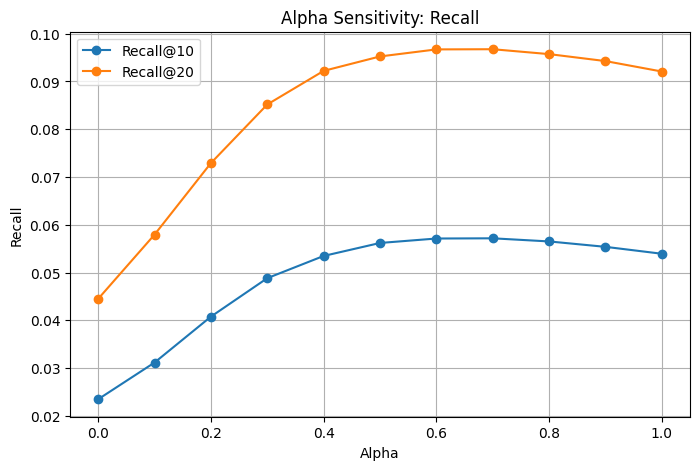

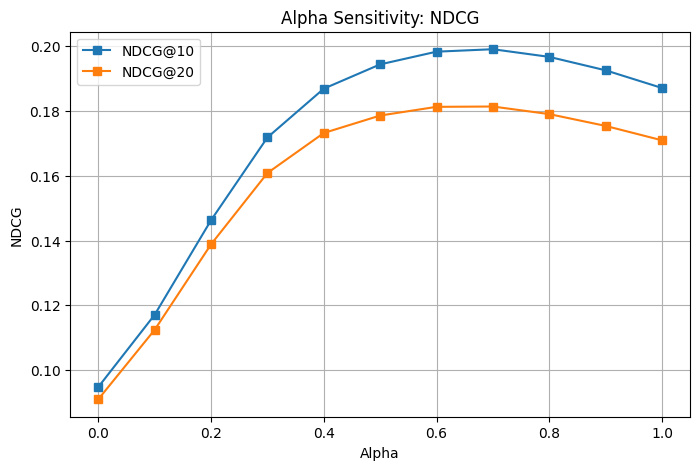

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(alpha_df["alpha"], alpha_df["Recall@10"], marker="o", label="Recall@10")
plt.plot(alpha_df["alpha"], alpha_df["Recall@20"], marker="o", label="Recall@20")
plt.xlabel("Alpha")
plt.ylabel("Recall")
plt.title("Alpha Sensitivity: Recall")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(alpha_df["alpha"], alpha_df["NDCG@10"], marker="s", label="NDCG@10")
plt.plot(alpha_df["alpha"], alpha_df["NDCG@20"], marker="s", label="NDCG@20")
plt.xlabel("Alpha")
plt.ylabel("NDCG")
plt.title("Alpha Sensitivity: NDCG")
plt.grid(True)
plt.legend()
plt.show()

## 12. Experiment 4: Score normalization ablation

This experiment checks whether fusion is affected by score scale mismatch between SASRec and LightGCN.

In [ ]:
norm_rows = []

for norm_method in ["none", "minmax", "zscore"]:
    # For each normalization method, search alpha and report the best result.
    best_metrics = None
    best_alpha_for_norm = None
    best_value = -float("inf")

    for alpha in CONFIG["ALPHAS"]:
        fused_scores = fuse_score_dicts(
            sasrec_scores=sasrec_scores,
            lightgcn_scores=lightgcn_scores,
            alpha=alpha,
            norm_method=norm_method,
        )

        metrics = evaluate_score_dict(
            fused_scores,
            user_train,
            user_test,
            ks=CONFIG["EVAL_KS"],
        )

        value = metrics[metric_to_select]

        if value > best_value:
            best_value = value
            best_metrics = metrics
            best_alpha_for_norm = alpha

    norm_rows.append({
        "Normalization": norm_method,
        "Best alpha": best_alpha_for_norm,
        **best_metrics,
    })

norm_df = pd.DataFrame(norm_rows)
norm_df

,Normalization,Best alpha,Recall@10,Recall@20,NDCG@10,NDCG@20
0,none,0.7,0.057271,0.097229,0.199976,0.182691
1,minmax,0.7,0.057214,0.096977,0.199423,0.181955
2,zscore,0.7,0.057161,0.096741,0.199029,0.181353


## 13. Experiment 5: Popularity and long-tail analysis

Metrics:

1. `AvgRecPopularity@K`: average training popularity of recommended items.
2. `LongTailRatio@K`: fraction of recommended items that are long-tail items.
3. `ItemCoverage@K`: fraction of all items that appear in any recommendation list.

Head/tail definition:

- Head items: top 20% most popular training items
- Tail items: remaining 80%

In [ ]:
def item_popularity_from_train(train_df, n_items):
    pop = np.zeros(n_items + 1, dtype=np.int64)
    counts = train_df["item"].value_counts()
    for item, cnt in counts.items():
        pop[int(item)] = int(cnt)
    return pop


item_pop = item_popularity_from_train(train_df, n_items)

def head_tail_split(item_pop, head_ratio=0.2):
    real_items = np.arange(1, len(item_pop))
    sorted_items = sorted(real_items, key=lambda x: item_pop[x], reverse=True)
    head_cutoff = int(len(sorted_items) * head_ratio)
    head_items = set(sorted_items[:head_cutoff])
    tail_items = set(sorted_items[head_cutoff:])
    return head_items, tail_items

head_items, tail_items = head_tail_split(item_pop, head_ratio=0.2)

print(f"Head items: {len(head_items):,}")
print(f"Tail items: {len(tail_items):,}")


def get_topk_recommendations(score_dict, user_train, k=10):
    recs = {}

    for u, scores in score_dict.items():
        scores = scores.copy()
        scores[0] = -1e9

        for item in set(user_train[u]):
            scores[item] = -1e9

        topk = np.argsort(-scores)[:k].tolist()
        recs[u] = topk

    return recs


def popularity_metrics(score_dict, user_train, item_pop, tail_items, k=10):
    recs = get_topk_recommendations(score_dict, user_train, k=k)

    all_rec_items = []
    avg_pop_by_user = []
    tail_ratio_by_user = []

    for u, items in recs.items():
        all_rec_items.extend(items)
        avg_pop_by_user.append(float(np.mean([item_pop[i] for i in items])))
        tail_ratio_by_user.append(float(np.mean([1.0 if i in tail_items else 0.0 for i in items])))

    item_coverage = len(set(all_rec_items)) / (len(item_pop) - 1)

    return {
        f"AvgPop@{k}": float(np.mean(avg_pop_by_user)),
        f"LongTailRatio@{k}": float(np.mean(tail_ratio_by_user)),
        f"ItemCoverage@{k}": float(item_coverage),
    }


pop_rows = []

for name, scores in [
    ("SASRec-only", sasrec_scores),
    ("LightGCN-only", lightgcn_scores),
    (f"Best Fusion alpha={best_alpha}", best_fusion_scores),
]:
    pop_metrics = popularity_metrics(
        score_dict=scores,
        user_train=user_train,
        item_pop=item_pop,
        tail_items=tail_items,
        k=10,
    )
    pop_rows.append({"Method": name, **pop_metrics})

pop_df = pd.DataFrame(pop_rows)
pop_df

Head items: 741
Tail items: 2,965


,Method,AvgPop@10,LongTailRatio@10,ItemCoverage@10
0,SASRec-only,729.107897,0.267748,0.716406
1,LightGCN-only,1137.436374,0.098526,0.479493
2,Best Fusion alpha=0.7,779.193974,0.237483,0.711279


## 14. Optional K=1..30 curves

These curves are useful for visualization, but final tables can focus on:

- Recall@10
- NDCG@10
- Recall@20
- NDCG@20

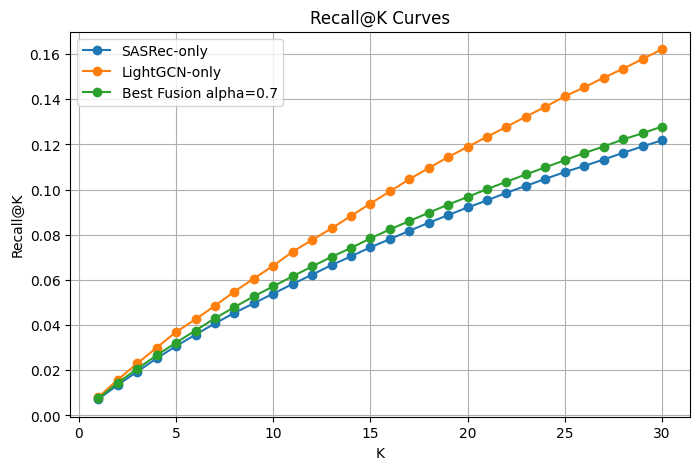

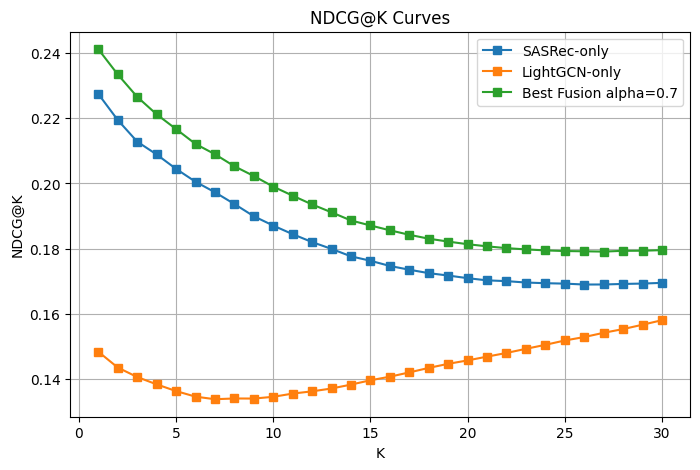

In [ ]:
def plot_k_curves(score_dicts, user_train, user_test, max_k=30):
    plt.figure(figsize=(8, 5))
    for name, scores in score_dicts.items():
        k_values, recalls, ndcgs = evaluate_score_dict_over_k(
            scores, user_train, user_test, max_k=max_k
        )
        plt.plot(k_values, recalls, marker="o", label=name)
    plt.xlabel("K")
    plt.ylabel("Recall@K")
    plt.title("Recall@K Curves")
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 5))
    for name, scores in score_dicts.items():
        k_values, recalls, ndcgs = evaluate_score_dict_over_k(
            scores, user_train, user_test, max_k=max_k
        )
        plt.plot(k_values, ndcgs, marker="s", label=name)
    plt.xlabel("K")
    plt.ylabel("NDCG@K")
    plt.title("NDCG@K Curves")
    plt.grid(True)
    plt.legend()
    plt.show()


plot_k_curves(
    {
        "SASRec-only": sasrec_scores,
        "LightGCN-only": lightgcn_scores,
        f"Best Fusion alpha={best_alpha}": best_fusion_scores,
    },
    user_train=user_train,
    user_test=user_test,
    max_k=CONFIG["CURVE_MAX_K"],
)

## 15. Final result summary

Use these tables in the report:

1. Shared protocol baseline comparison.
2. Alpha sensitivity analysis.
3. Normalization ablation.
4. Popularity / long-tail analysis.

In [ ]:
shared_summary_df = pd.DataFrame([
    {"Method": "SASRec-only", **sasrec_metrics},
    {"Method": "LightGCN-only", **lightgcn_metrics},
    { "Method": f"Best Fusion alpha={best_alpha}", **best_fusion_metrics},
])

print("Shared Protocol Comparison")
display(shared_summary_df)

print("Alpha Sensitivity")
display(alpha_df)

print("Normalization Ablation")
display(norm_df)

print("Popularity / Long-tail Analysis")
display(pop_df)

Shared Protocol Comparison


,Method,Recall@10,Recall@20,NDCG@10,NDCG@20
0,SASRec-only,0.053927,0.092073,0.187071,0.170927
1,LightGCN-only,0.066292,0.118892,0.134501,0.145677
2,Best Fusion alpha=0.7,0.057161,0.096741,0.199029,0.181353


Alpha Sensitivity


,alpha,Recall@10,Recall@20,NDCG@10,NDCG@20
0,0.0,0.023478,0.044496,0.094830,0.091052
1,0.1,0.031159,0.057942,0.117122,0.112480
2,0.2,0.040768,0.072912,0.146284,0.138844
3,0.3,0.048819,0.085179,0.171811,0.160836
4,0.4,0.053469,0.092209,0.186861,0.173183
5,0.5,0.056187,0.095230,0.194356,0.178569
6,0.6,0.057118,0.096704,0.198272,0.181252
7,0.7,0.057161,0.096741,0.199029,0.181353
8,0.8,0.056506,0.095716,0.196667,0.179015
9,0.9,0.055375,0.094258,0.192522,0.175370


Normalization Ablation


,Normalization,Best alpha,Recall@10,Recall@20,NDCG@10,NDCG@20
0,none,0.7,0.057271,0.097229,0.199976,0.182691
1,minmax,0.7,0.057214,0.096977,0.199423,0.181955
2,zscore,0.7,0.057161,0.096741,0.199029,0.181353


Popularity / Long-tail Analysis


,Method,AvgPop@10,LongTailRatio@10,ItemCoverage@10
0,SASRec-only,729.107897,0.267748,0.716406
1,LightGCN-only,1137.436374,0.098526,0.479493
2,Best Fusion alpha=0.7,779.193974,0.237483,0.711279
